# Librerías

In [1]:
import os
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

### 1. Lectura de datos

Leemos los datos

In [2]:
hcc1_ann = sc.read_10x_mtx("data/GSE166635_RAW/GSM5076749_HCC1")

Coste lectura: 1m 14s - 18s

In [3]:
# Tamaño 16077 x 33694 (barcode x feature / células x genes)
hcc1_ann

AnnData object with n_obs × n_vars = 16077 × 33694
    var: 'gene_ids', 'feature_types'

In [4]:
print(hcc1_ann.obs)
print(hcc1_ann.var)

Empty DataFrame
Columns: []
Index: [AAACCCAAGAAGAACG-1, AAACCCAAGCAACAAT-1, AAACCCAAGCATCTTG-1, AAACCCAAGCTGAGTG-1, AAACCCACAAGGGCAT-1, AAACCCACAGCTGAAG-1, AAACCCACATAACGGG-1, AAACCCAGTAGCTGCC-1, AAACCCAGTATAGGAT-1, AAACCCAGTATGGGAC-1, AAACCCAGTCAACACT-1, AAACCCAGTGTCTTCC-1, AAACCCAGTTAAGGAT-1, AAACCCAGTTTCACTT-1, AAACCCATCAACTGAC-1, AAACCCATCAAGTTGC-1, AAACCCATCAGCATTG-1, AAACCCATCGTGCATA-1, AAACCCATCTGAGGTT-1, AAACCCATCTTGATTC-1, AAACGAAAGAGCAGCT-1, AAACGAACAACGATTC-1, AAACGAACAATTGCGT-1, AAACGAACACACCTAA-1, AAACGAAGTTAGGGTG-1, AAACGAAGTTTACGTG-1, AAACGAATCCATGATG-1, AAACGAATCGATTTCT-1, AAACGAATCTACGGTA-1, AAACGAATCTATCGGA-1, AAACGAATCTGACGCG-1, AAACGCTAGGCGTCCT-1, AAACGCTAGGTGGGTT-1, AAACGCTAGTGCTACT-1, AAACGCTCAAACACGG-1, AAACGCTCAACGGTAG-1, AAACGCTCAAGCGGAT-1, AAACGCTCACCTGATA-1, AAACGCTCACTACACA-1, AAACGCTCACTGTCGG-1, AAACGCTCAGAAGCTG-1, AAACGCTCAGTAGAAT-1, AAACGCTGTAGTGGCA-1, AAACGCTGTCACTCGG-1, AAACGCTGTTAGGGTG-1, AAACGCTGTTCGGCGT-1, AAACGCTGTTTATGCG-1, AAACGCTTCCGTAATG-1, AAAC

In [5]:
print(hcc1_ann.X)

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 41342896 stored elements and shape (16077, 33694)>
  Coords	Values
  (275, 3)	1.0
  (863, 3)	1.0
  (913, 3)	1.0
  (1396, 3)	1.0
  (2698, 3)	1.0
  (5135, 3)	1.0
  (5314, 3)	1.0
  (5383, 3)	1.0
  (5680, 3)	1.0
  (6483, 3)	1.0
  (6936, 3)	1.0
  (7891, 3)	1.0
  (7996, 3)	1.0
  (8013, 3)	1.0
  (9824, 3)	1.0
  (10326, 3)	1.0
  (11600, 3)	1.0
  (12048, 3)	1.0
  (12080, 3)	1.0
  (15432, 3)	1.0
  (16063, 3)	1.0
  (305, 6)	1.0
  (347, 6)	1.0
  (1093, 6)	1.0
  (2701, 6)	1.0
  :	:
  (14852, 33691)	1.0
  (14879, 33691)	2.0
  (14913, 33691)	1.0
  (14978, 33691)	1.0
  (15142, 33691)	1.0
  (15174, 33691)	2.0
  (15188, 33691)	1.0
  (15248, 33691)	1.0
  (15281, 33691)	1.0
  (15287, 33691)	1.0
  (15344, 33691)	1.0
  (15403, 33691)	1.0
  (15416, 33691)	1.0
  (15472, 33691)	1.0
  (15502, 33691)	1.0
  (15512, 33691)	1.0
  (15625, 33691)	1.0
  (15748, 33691)	1.0
  (15838, 33691)	1.0
  (15898, 33691)	1.0
  (15904, 33691)	1.0
  (15940, 33691)	1.0

### 2. Limpieza de datos

Pasamos a limpiar las muestras que no tienen sentido, lo que queremos obtener al final:

    - células con número de genes entre 200 y 7000
    - células con proporción de mitocondria menor de 20%
    - genes expresados en 4 células o más

In [3]:
# Añadimos columna a var paragenes mitocondriales, MT- para referir a genes mitocondriales de humanos
hcc1_ann.var["mt"] = hcc1_ann.var_names.str.startswith("MT-")

# Calculamos métricas de control de calidad, añadimos la variable que nos interesa "mt"
sc.pp.calculate_qc_metrics(hcc1_ann, qc_vars=["mt"], inplace=True)
# Se modifica directamente la matriz, añadiendo columnas de métricas

In [4]:
hcc1_ann.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
AAACCCAAGAAGAACG-1,1729,7.455877,5173.0,8.551401,36.149236,47.322637,58.901991,73.864295,413.0,6.025866,7.983762
AAACCCAAGCAACAAT-1,3782,8.238273,13257.0,9.492356,25.571396,34.917402,46.360413,61.597647,905.0,6.809039,6.826582
AAACCCAAGCATCTTG-1,2750,7.919720,9418.0,9.150484,29.507326,41.293268,53.695052,68.273519,721.0,6.582025,7.655553
AAACCCAAGCTGAGTG-1,1448,7.278629,4960.0,8.509362,37.923387,50.383065,64.193548,79.979839,257.0,5.552959,5.181451
AAACCCACAAGGGCAT-1,2080,7.640604,8340.0,9.028938,40.671463,50.539568,61.486811,76.294964,314.0,5.752573,3.764988
...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGTCAGGTGTT-1,735,6.601230,1366.0,7.220374,32.723280,45.461201,60.395315,82.796486,76.0,4.343805,5.563690
TTTGTTGTCCAAATGC-1,2014,7.608374,5809.0,8.667336,34.962988,45.205715,56.326390,70.511276,448.0,6.107023,7.712171
TTTGTTGTCTAACGCA-1,2156,7.676474,5918.0,8.685923,36.059480,44.237918,53.531599,67.641095,766.0,6.642487,12.943562
TTTGTTGTCTCAGGCG-1,2961,7.993620,15018.0,9.617071,64.862165,69.383407,73.944600,80.550007,7243.0,8.887929,48.228790


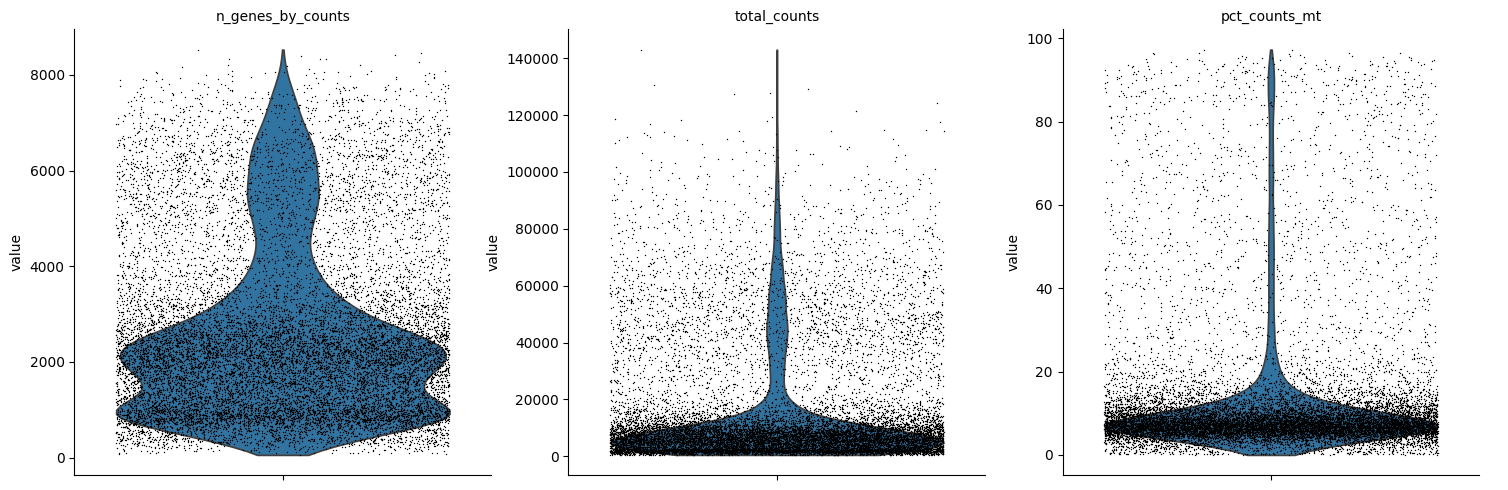

In [11]:
sc.pl.violin(
    hcc1_ann,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

En las gráficas que se muestran previamente, podemos ver la distribución de datos y dónde hay más densidad, esto puede ser una **clave** para determinar los umbrales de filtrado.

<Axes: xlabel='pct_counts_mt', ylabel='Count'>

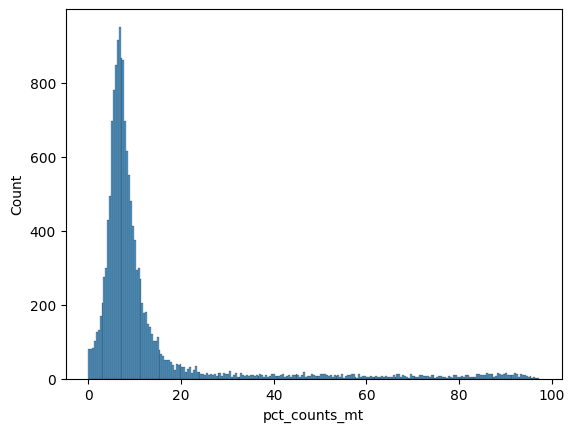

In [15]:
sns.histplot(hcc1_ann.obs["pct_counts_mt"])

En el histograma se puede comprobar que el valor de filtrado de 20% de proporción mitocondria (ligeramente permisivo) puede ser lógico, dado que hay una gran concentración de datos que están en esa zona.

#### 2.1. Filtrado por número de genes y células

Miramos principalmente el "**n_genes_by_counts**", que es la métrica que cuenta el número de genes que tiene mínimo un *count* (existe) en la célula. Es decir, número de genes que tiene una célula. También hay que reducir los genes que no tienen un número mínimo de apariciones en células.

In [4]:
hcc1_filter_gen_counts = hcc1_ann[(hcc1_ann.obs["n_genes_by_counts"] >= 200) & (hcc1_ann.obs["n_genes_by_counts"] <= 7000)].copy()

# También se podría hacer:
#sc.pp.filter_cells(hcc1_filter_gen_counts, min_genes=200)
#sc.pp.filter_cells(hcc1_filter_gen_counts, max_genes=7000)

sc.pp.filter_genes(hcc1_filter_gen_counts, min_cells=4) # Filtramos genes que no estén expresado en al menos 4 células

# 15609 células y 21815 genes resultantes
print(hcc1_filter_gen_counts.obs["n_genes_by_counts"])

AAACCCAAGAAGAACG-1    1729
AAACCCAAGCAACAAT-1    3782
AAACCCAAGCATCTTG-1    2750
AAACCCAAGCTGAGTG-1    1448
AAACCCACAAGGGCAT-1    2080
                      ... 
TTTGTTGTCAGGTGTT-1     735
TTTGTTGTCCAAATGC-1    2014
TTTGTTGTCTAACGCA-1    2156
TTTGTTGTCTCAGGCG-1    2961
TTTGTTGTCTGGTGGC-1    5943
Name: n_genes_by_counts, Length: 15609, dtype: int64


In [5]:
hcc1_filter_gen_counts.var

,gene_ids,feature_types,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
RP11-34P13.7,ENSG00000238009,Gene Expression,False,21,0.001306,0.001305,99.869379,21.0,3.091043,17
RP11-34P13.9,ENSG00000241599,Gene Expression,False,9,0.000560,0.000560,99.944019,9.0,2.302585,8
FO538757.2,ENSG00000279457,Gene Expression,False,1205,0.081607,0.078448,92.504821,1312.0,7.180070,1084
AP006222.2,ENSG00000228463,Gene Expression,False,2027,0.152640,0.142055,87.391926,2454.0,7.805882,1798
RP4-669L17.10,ENSG00000237094,Gene Expression,False,93,0.005971,0.005954,99.421534,96.0,4.574711,77
...,...,...,...,...,...,...,...,...,...,...
AC007325.4,ENSG00000278817,Gene Expression,False,1228,0.097655,0.093176,92.361759,1570.0,7.359468,1035
AL354822.1,ENSG00000278384,Gene Expression,False,990,0.073770,0.071176,93.842135,1186.0,7.079185,859
AC004556.1,ENSG00000276345,Gene Expression,False,2150,0.170119,0.157105,86.626858,2735.0,7.914252,1920
AC233755.2,ENSG00000277856,Gene Expression,False,8,0.001368,0.001367,99.950239,22.0,3.135494,8


In [ ]:
# Miramos los datos que han sido filtrados
hcc1_gen_counts_left = hcc1_ann[(hcc1_ann.obs["n_genes_by_counts"] < 200) | (hcc1_ann.obs["n_genes_by_counts"] > 7000)]

hcc1_lower_bound_gen_counts = hcc1_ann[hcc1_ann.obs["n_genes_by_counts"] < 200]

hcc1_upper_bound_gen_counts = hcc1_ann[hcc1_ann.obs["n_genes_by_counts"] > 7000]

# Crear fichero csv con los datos para analizar
#hcc1_gen_counts_left.obs.to_csv("hcc1_gen_counts_left_obs.csv")
#hcc1_lower_bound_gen_counts.obs.to_csv("hcc1_lower_bound_gen_counts.csv")
#hcc1_upper_bound_gen_counts.obs.to_csv("hcc1_upper_bound_gen_counts.csv")

El límite para abajo se puede fijar a 200, los datos no sirven si intentamos bajar el umbral, no obstante, se puede mirar el límite por arriba, comprobar si se puede ser más permisivo.

Se va a probar con 7200 y 7500 como extremo, miramos los datos entre 7000 - 7200 y 7200 - 7500

In [ ]:
hcc1_upper_bound_A = hcc1_ann[(hcc1_ann.obs["n_genes_by_counts"] > 7000) & (hcc1_ann.obs["n_genes_by_counts"] < 7201)]
hcc1_upper_bound_B = hcc1_ann[(hcc1_ann.obs["n_genes_by_counts"] > 7200) & (hcc1_ann.obs["n_genes_by_counts"] < 7501)]

#hcc1_upper_bound_A.obs.to_csv("hcc1_upper_bound_A.csv")
#hcc1_upper_bound_B.obs.to_csv("hcc1_upper_bound_B.csv")

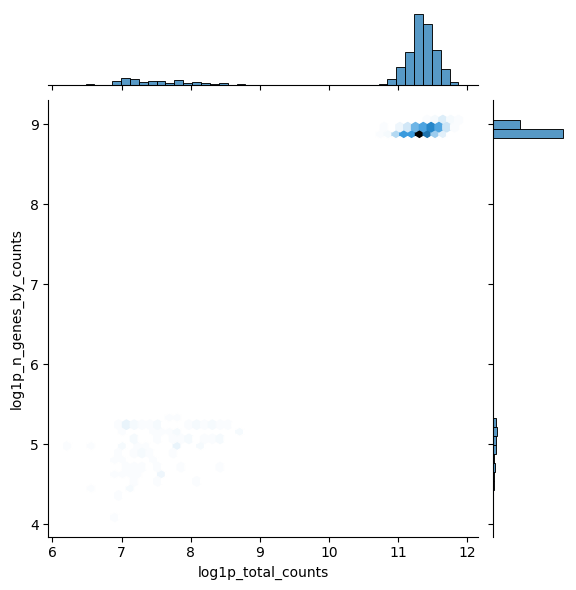

In [9]:
sns.jointplot(
    data=hcc1_gen_counts_left.obs,
    x="log1p_total_counts",
    y="log1p_n_genes_by_counts",
    kind="hex",
)

<Axes: xlabel='pct_counts_mt', ylabel='Count'>

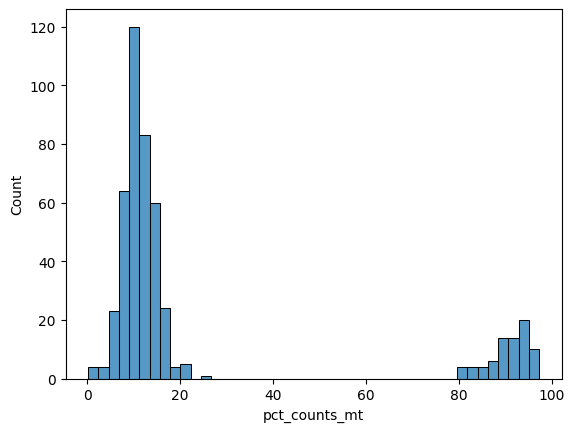

In [10]:
sns.histplot(hcc1_gen_counts_left.obs["pct_counts_mt"])

Gran parte de los datos filtrados son datos con más de 7000 genes, lo que significa que en esta recolección hay varias muestras con posiblemente más de una célula.

Los datos menos frecuentes tienen una proporción de mitocondria exagerada (80 - 90%). Si se analiza los datos, se puede ver que el "total_counts_mt" (cuenta de genes MT) es un valor cercano a "total_counts" (cuenta de la célula), básicamente indica que estas células están dañadas o son de baja calidad.

#### 2.2. Filtrado por mitocondria

In [5]:
hcc1_filtered = hcc1_filter_gen_counts[(hcc1_filter_gen_counts.obs["pct_counts_mt"] <= 20)]

# 13883 muestras resultantes
hcc1_filtered.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
AAACCCAAGAAGAACG-1,1729,7.455877,5173.0,8.551401,36.149236,47.322637,58.901991,73.864295,413.0,6.025866,7.983762
AAACCCAAGCAACAAT-1,3782,8.238273,13257.0,9.492356,25.571396,34.917402,46.360413,61.597647,905.0,6.809039,6.826582
AAACCCAAGCATCTTG-1,2750,7.919720,9418.0,9.150484,29.507326,41.293268,53.695052,68.273519,721.0,6.582025,7.655553
AAACCCAAGCTGAGTG-1,1448,7.278629,4960.0,8.509362,37.923387,50.383065,64.193548,79.979839,257.0,5.552959,5.181451
AAACCCACAAGGGCAT-1,2080,7.640604,8340.0,9.028938,40.671463,50.539568,61.486811,76.294964,314.0,5.752573,3.764988
...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGTCAGCATTG-1,5380,8.590630,30589.0,10.328428,33.750695,43.927556,54.058649,66.422570,3190.0,8.068089,10.428585
TTTGTTGTCAGGTGTT-1,735,6.601230,1366.0,7.220374,32.723280,45.461201,60.395315,82.796486,76.0,4.343805,5.563690
TTTGTTGTCCAAATGC-1,2014,7.608374,5809.0,8.667336,34.962988,45.205715,56.326390,70.511276,448.0,6.107023,7.712171
TTTGTTGTCTAACGCA-1,2156,7.676474,5918.0,8.685923,36.059480,44.237918,53.531599,67.641095,766.0,6.642487,12.943562


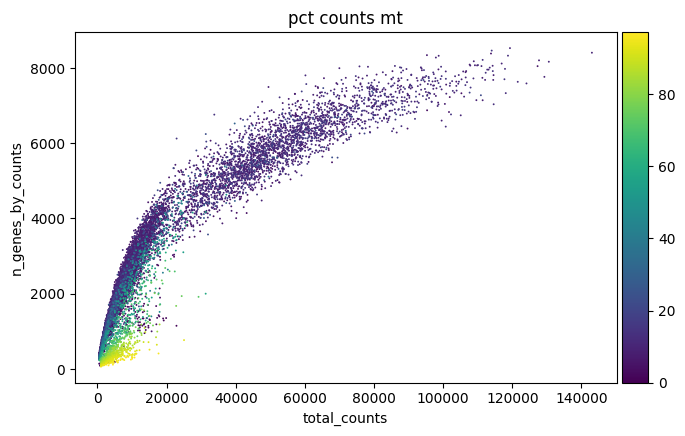

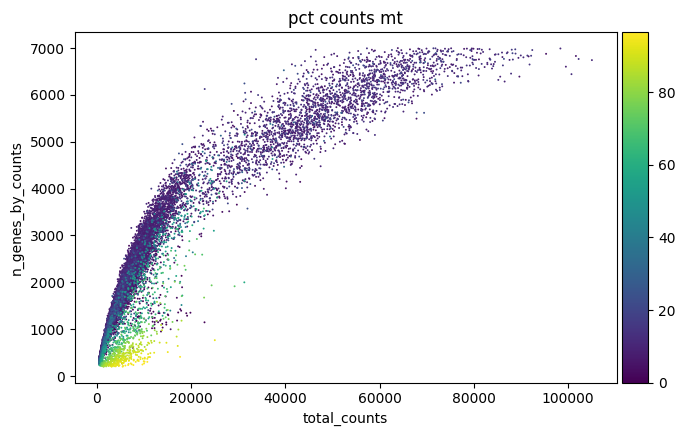

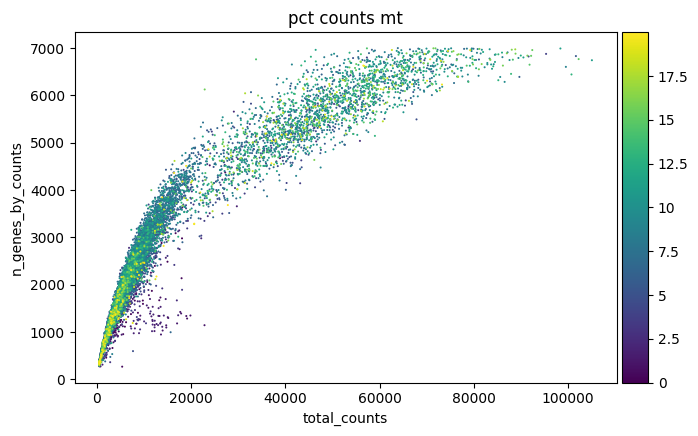

In [15]:
sc.pl.scatter(hcc1_ann, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

sc.pl.scatter(hcc1_filter_gen_counts, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

sc.pl.scatter(hcc1_filtered, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

El primer filtrado hace un corte por arriba y abajo del total de las muestras, luego en el segundo filtrado se eliminan bastantes datos de la parte inferior izquierda, en comparación con las primeras gráficas.

Los datos que se quitan en el segundo cribado tienen menor total_counts, número total de cuentas para una célula y n_genes_by_counts, es decir, no están muy expresados en comparación con el conjunto total (se quitan las células de baja calidad, mucha mitocondria en comparación con la "cantidad" de célula).

#### 2.3. Doublets

En técnicas modernas de secuenciación de células individuales (scRNA-seq), un doublet ocurre cuando dos células quedan atrapadas juntas en la misma gota o pocillo durante el aislamiento. El secuenciador las lee como si fueran una sola célula, lo que puede causar errores en los datos si no se filtran computacionalmente.

In [ ]:
hcc1_filter_A = hcc1_ann[(hcc1_ann.obs["n_genes_by_counts"] >= 200) & (hcc1_ann.obs["n_genes_by_counts"] <= 7200)]

hcc1_filter_B = hcc1_ann[(hcc1_ann.obs["n_genes_by_counts"] >= 200) & (hcc1_ann.obs["n_genes_by_counts"] <= 7500)]

# He ejecutado el scrublets con esto y no ha hecho nada. Parámetros o es que da igual.

In [ ]:
# Dejo todos los parámetros por defecto, por probar
hcc1_no_doublet = sc.pp.scrublet(hcc1_filtered, copy=True)

# 10m

In [ ]:
hcc1_no_doublet_A = sc.pp.scrublet(hcc1_upper_bound_A, copy=True)

In [15]:
hcc1_no_doublet_B = sc.pp.scrublet(hcc1_upper_bound_B, copy=True)

In [14]:
hcc1_no_doublet_A.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,doublet_score,predicted_doublet
AAACCCATCAGCATTG-1,7033,8.858511,56426.0,10.940703,34.565626,47.176833,56.922341,67.732960,3225.0,8.078999,5.715450,0.078788,False
AAACGCTAGGTGGGTT-1,7109,8.869258,73873.0,11.210116,36.450395,46.255059,56.712195,69.125391,6815.0,8.827028,9.225292,0.078788,False
AAACGCTTCTGACAGT-1,7071,8.863899,65883.0,11.095651,37.773022,47.673907,57.338008,69.142267,6241.0,8.739056,9.472854,0.059406,False
AACCCAAGTCCTCCTA-1,7005,8.854522,81870.0,11.312901,39.816783,51.600098,62.744595,73.884207,7636.0,8.940760,9.326982,0.028754,False
AAGTGAATCGGCTATA-1,7047,8.860499,80433.0,11.295193,41.475514,52.425000,62.619820,73.992018,9540.0,9.163354,11.860804,0.036232,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGGGATGTGCGGCTT-1,7056,8.861775,69885.0,11.154620,39.224440,50.960864,60.878586,71.484582,5613.0,8.633018,8.031766,0.046025,False
TTGGGTACACTCGATA-1,7051,8.861067,82430.0,11.319716,40.049739,53.987626,64.602693,74.608759,7035.0,8.858795,8.534514,0.046025,False
TTTACGTTCTGGTGGC-1,7186,8.880029,69830.0,11.153833,34.008306,45.791207,56.510096,68.324502,6047.0,8.707483,8.659602,0.078788,False
TTTAGTCAGCTGGAGT-1,7068,8.863474,63925.0,11.065481,37.863121,50.075870,59.084865,69.515839,6083.0,8.713418,9.515839,0.059406,False


In [16]:
hcc1_no_doublet_B.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,doublet_score,predicted_doublet
AAACCCATCAACTGAC-1,7236,8.886962,69085.0,11.143107,42.505609,52.706087,61.738438,71.744952,11185.0,9.322418,16.190201,0.057851,False
AAAGGGCGTATTCTCT-1,7258,8.889997,69982.0,11.156008,33.928725,44.107056,54.936984,67.881741,9600.0,9.169622,13.717813,0.073171,False
AAAGTGAAGTACTGGG-1,7474,8.919319,78647.0,11.272738,36.668913,46.678195,57.806401,70.338347,8648.0,9.065199,10.995969,0.057851,False
AACCAACCATCACAGT-1,7463,8.917847,78177.0,11.266744,37.498241,49.001625,59.456106,70.048736,8710.0,9.072342,11.141384,0.057851,False
AACCCAAAGCCTCAAT-1,7339,8.901094,95962.0,11.471718,44.585357,56.939205,66.510702,75.816469,13938.0,9.542446,14.524499,0.037975,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGGTTTCACGGTCTG-1,7238,8.887238,106054.0,11.571713,43.500481,57.036981,66.696211,76.623230,12116.0,9.402365,11.424369,0.095238,False
TTGGTTTTCCGTCACT-1,7347,8.902183,64439.0,11.073490,38.149257,48.535825,57.716600,68.157482,5120.0,8.541105,7.945499,0.037975,False
TTTCCTCTCCCTTTGG-1,7499,8.922658,87510.0,11.379519,37.182036,45.746772,55.499943,67.602560,10062.0,9.216620,11.498115,0.046595,False
TTTGATCCATGCAGCC-1,7376,8.906122,59084.0,10.986732,35.116106,43.529551,52.987272,64.712951,10828.0,9.289983,18.326450,0.095238,False


In [12]:
hcc1_no_doublet.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,doublet_score,predicted_doublet
AAACCCAAGAAGAACG-1,1729,7.455877,5173.0,8.551401,36.149236,47.322637,58.901991,73.864295,413.0,6.025866,7.983762,0.074709,False
AAACCCAAGCAACAAT-1,3782,8.238273,13257.0,9.492356,25.571396,34.917402,46.360413,61.597647,905.0,6.809039,6.826582,0.091731,False
AAACCCAAGCATCTTG-1,2750,7.919720,9418.0,9.150484,29.507326,41.293268,53.695052,68.273519,721.0,6.582025,7.655553,0.030190,False
AAACCCAAGCTGAGTG-1,1448,7.278629,4960.0,8.509362,37.923387,50.383065,64.193548,79.979839,257.0,5.552959,5.181451,0.041187,False
AAACCCACAAGGGCAT-1,2080,7.640604,8340.0,9.028938,40.671463,50.539568,61.486811,76.294964,314.0,5.752573,3.764988,0.008504,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGTCAGCATTG-1,5380,8.590630,30589.0,10.328428,33.750695,43.927556,54.058649,66.422570,3190.0,8.068089,10.428585,0.027670,False
TTTGTTGTCAGGTGTT-1,735,6.601230,1366.0,7.220374,32.723280,45.461201,60.395315,82.796486,76.0,4.343805,5.563690,0.009822,False
TTTGTTGTCCAAATGC-1,2014,7.608374,5809.0,8.667336,34.962988,45.205715,56.326390,70.511276,448.0,6.107023,7.712171,0.025363,False
TTTGTTGTCTAACGCA-1,2156,7.676474,5918.0,8.685923,36.059480,44.237918,53.531599,67.641095,766.0,6.642487,12.943562,0.016619,False


No hay diferencia, dejo los datos filtrados sin ejecutar **scrublet()**.

#### 2.4. Normalización

Dejamos los datos en un intervalo más manejable.

In [6]:
# Saving count data
hcc1_filtered.layers["counts"] = hcc1_filtered.X.copy()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4668\2911544399.py:2: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  hcc1_filtered.layers["counts"] = hcc1_filtered.X.copy()


In [7]:
hcc1_normalized = hcc1_filtered.copy()

# Normalización (mediana del número total de cuentas)
sc.pp.normalize_total(hcc1_normalized)

# Transformación logarítmica
sc.pp.log1p(hcc1_normalized)

In [16]:
print(hcc1_normalized.X)

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 35523923 stored elements and shape (13883, 21815)>
  Coords	Values
  (0, 19)	0.8528058528900146
  (0, 28)	0.8528058528900146
  (0, 79)	0.8528058528900146
  (0, 86)	0.8528058528900146
  (0, 110)	1.3062878847122192
  (0, 136)	1.3062878847122192
  (0, 142)	3.2800910472869873
  (0, 144)	0.8528058528900146
  (0, 156)	0.8528058528900146
  (0, 160)	0.8528058528900146
  (0, 188)	0.8528058528900146
  (0, 192)	0.8528058528900146
  (0, 197)	0.8528058528900146
  (0, 200)	1.6171406507492065
  (0, 247)	0.8528058528900146
  (0, 250)	0.8528058528900146
  (0, 251)	1.3062878847122192
  (0, 254)	0.8528058528900146
  (0, 268)	1.3062878847122192
  (0, 269)	0.8528058528900146
  (0, 290)	1.3062878847122192
  (0, 304)	0.8528058528900146
  (0, 308)	2.9880573749542236
  (0, 309)	2.7605433464050293
  (0, 310)	2.9880573749542236
  :	:
  (13882, 21756)	0.1813645213842392
  (13882, 21757)	0.1813645213842392
  (13882, 21758)	0.4678489863872528
  (13882, 2

La normalización que se usa es el que por defecto ofrece scanpy, donde se le divide por la mediana del total de cuentas de células.

Una vez tenemos los datos normalizados, hay que reducir la dimensión, escogiendo solo los genes más informativos (más variación), más o menos 2000.

In [11]:
hcc1_high_var = hcc1_normalized.copy()

Se va a probar las distintas implementaciones para escoger los genes con más variación: '*seurat*', '*cell_ranger*', '*seurat_v3*' y '*seurat_v3_paper*'.

Las dos primeras implementaciones escogen los genes basado en una **dispersión normalizada**, que se obtiene agrupando los genes en base a su expresión media en un '*bin*'. Para cada '*bin*' se **escala** la dispersión de los genes con la media y desviación estándar de las dispersiones de los genes dentro '*bin*'. Finalmente se escogen los genes designados de cada '*bin*'.

La diferencia entre '*seurat*' y '*cell_ranger*' es que '*seurat*' calcula el z-score ($z = \frac{x - \mu}{\sigma}$) y '*cell_ranger*' computa la diferencia absoluta entre la dispersión y dispersión mediana de cada bin, dividido entre la desviación absoluta de la mediana (MAD).

Para '*seurat_v3*' y '*seurat_v3_paper*' esperan datos sin logaritmizar a diferencia de los anteriores y devuelven una varianza normalizada para cada gen. Los datos se estandarizan con una desviación estándar regularizada, después la varianza normalizada se calcula como la varianza de cada gen. No hay diferencia entre los dos si **batch_key=None**

Estas técnicas utilizadas evitan escoger directamente los genes con más varianza, dado que la varianza puede ser acumulada a base de un mayor número de expresiones de un gen. Se puede usar un criterio más justo para conseguir los genes con más información.

In [12]:
sc.pp.highly_variable_genes(hcc1_high_var, n_top_genes=2000, flavor='cell_ranger')    # flavor params: 'seurat', 'cell_ranger'

In [7]:
sc.pp.highly_variable_genes(hcc1_filtered, layer='counts', n_top_genes=2000, flavor='seurat_v3')    # flavor params: 'seurat_v3', 'seurat_v3_paper'

##### 2.4.1. Seurat

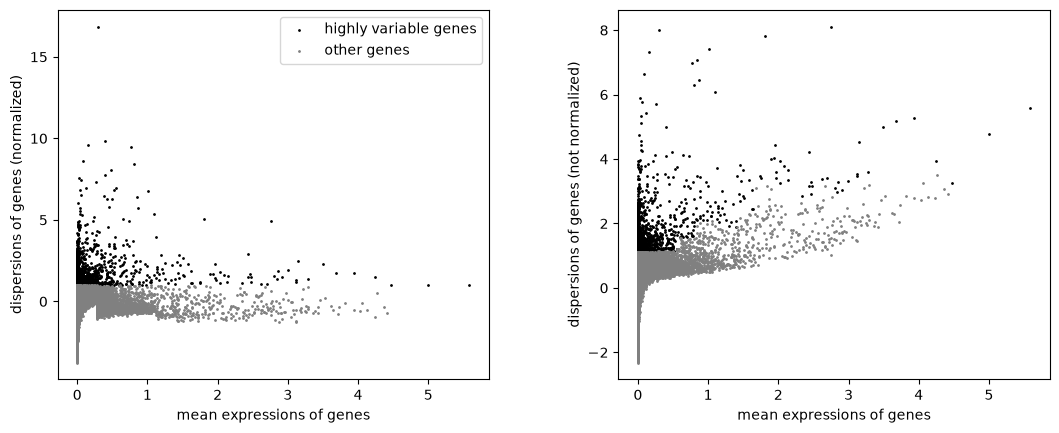

In [18]:
sc.pl.highly_variable_genes(hcc1_high_var)

Se puede ver una clara línea de separación entre los genes más informativos y no, puede no ser muy apto porque deja pasar algún dato que está muy expresado. No es muy robusto.

##### 2.4.2. Cell Ranger

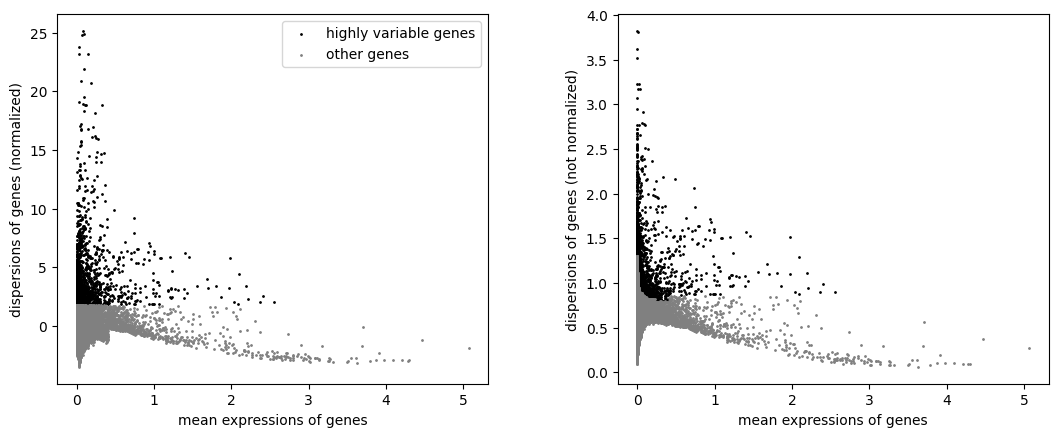

In [10]:
sc.pl.highly_variable_genes(hcc1_high_var)

Se parece de alguna forma al anterior, pero parece más robusto frente al ruido y tiene métricas distintas al ser dos formas de cálculo distintos.

##### 2.4.3. Seurat v3

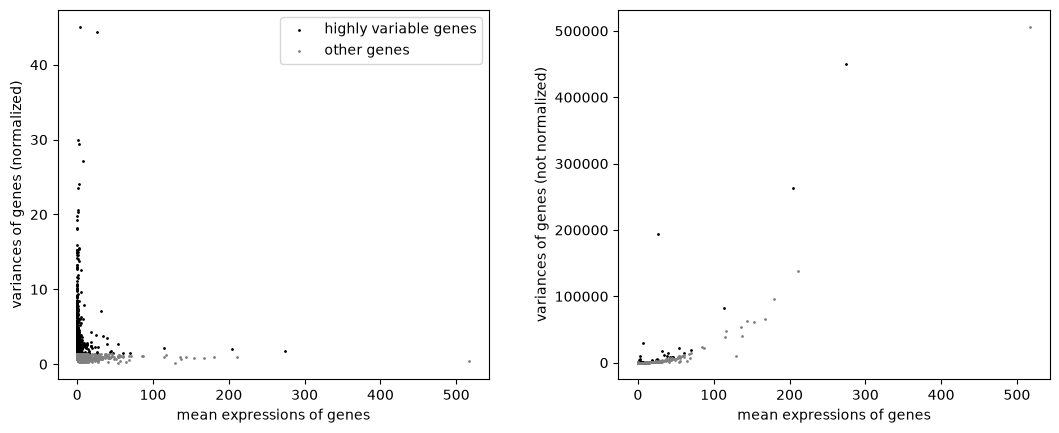

In [9]:
sc.pl.highly_variable_genes(hcc1_filtered)

Este último método parece ser el adecuado, en la gráfica de la izquierda (normalizada), se concentran los genes seleccionados en una expresión media de menor grado.

En el caso de usar este método hay que calcular los genes más variables primero y normalizar porteriormente, como se hace seguidamente:

In [8]:
hcc1_normalized = hcc1_filtered.copy()

# Normalización (mediana del número total de cuentas)
sc.pp.normalize_total(hcc1_normalized)

# Transformación logarítmica
sc.pp.log1p(hcc1_normalized)

#### 2.5. Reducción de dimensionalidad (PCA)

In [9]:
# Dejo el "zero_center" por defecto, que es True, no hay mucha preocupación de momento por eficiencia.
# "chunked" tampoco parece ser necesario, default False
# svd_solver='arpack'
sc.tl.pca(hcc1_normalized, n_comps=50)

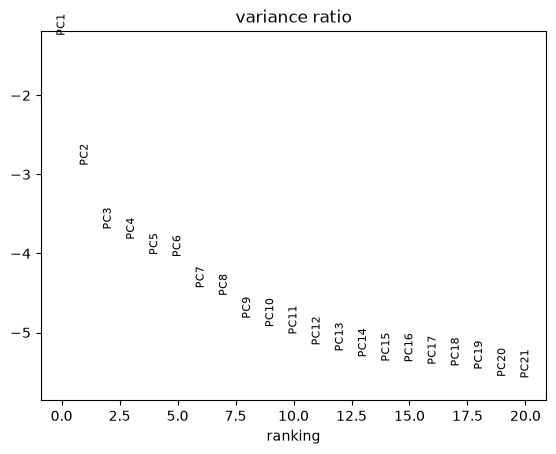

In [ ]:
sc.pl.pca_variance_ratio(hcc1_normalized, n_pcs=20, log=True)   # Dibujar 20 componentes

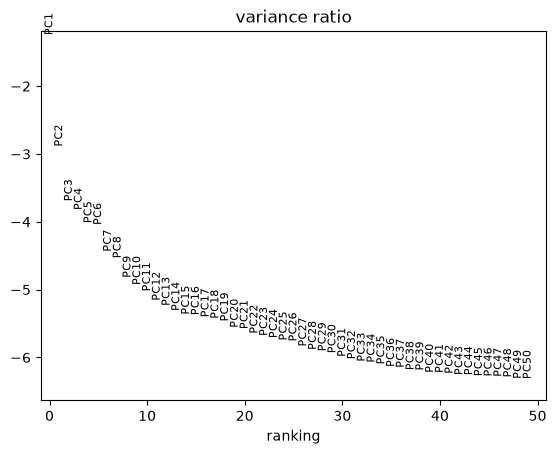

In [ ]:
sc.pl.pca_variance_ratio(hcc1_normalized, n_pcs=50, log=True)   # Dibujar 50 componentes

Usamos 50 componentes principales de momento, según la documentación no pasa nada por sobreestimar el número, después si vemos que sobreajustamos pues se puede reducir.

No obstante, se puede ver que a partir de PC 11-20, se va estabilizando la varianza por lo que usar un número de componentes de entre ese número, ya tendríamos la información importante necesaria.

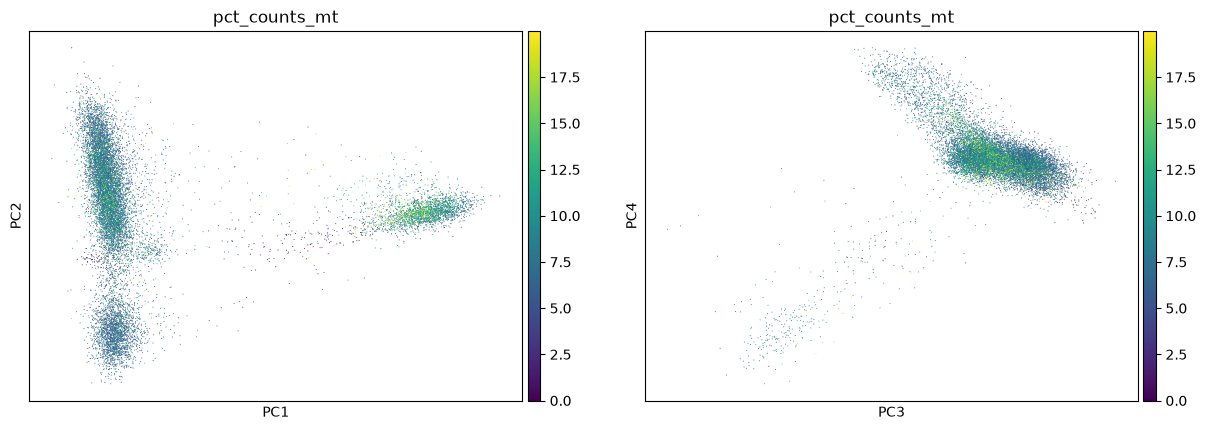

In [ ]:
sc.pl.pca(
    hcc1_normalized,
    color=["pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3)],
    ncols=2,
    size=2,
)

Las células con mayor concentración de mitocondria están localizadas en posiciones más altas de la gráfica.

### 3. Clasificación de datos

#### 3.1. KNN

Uso los parámetros por defecto para las siguientes celdas de momento.

In [10]:
sc.pp.neighbors(hcc1_normalized)

c:\Users\Usuario\Desktop\Zar4\TFG\tfg\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 3.2. Representación de clústers

In [11]:
sc.tl.tsne(hcc1_normalized)

In [12]:
sc.tl.umap(hcc1_normalized)

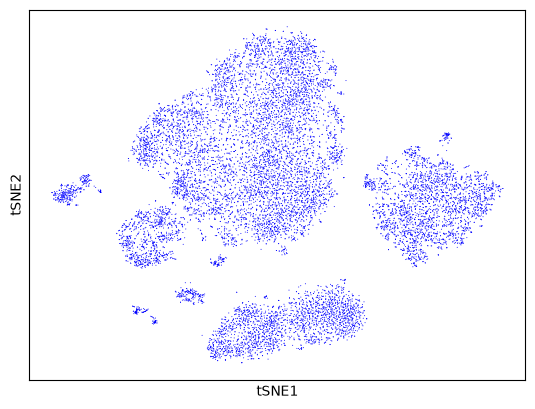

In [16]:
sc.pl.tsne(
    hcc1_normalized,
    # Setting a smaller point size to get prevent overlap
    size=2,
    na_color='blue'
)

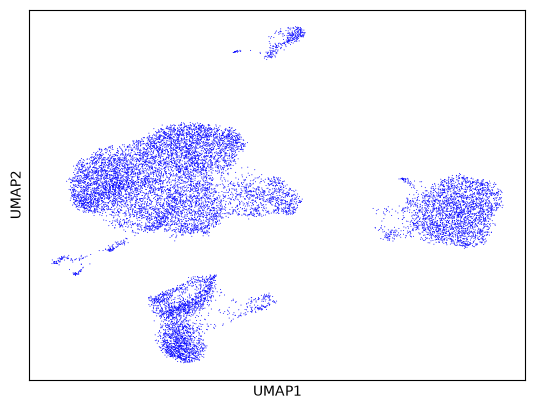

In [18]:
sc.pl.umap(
    hcc1_normalized,
    # Setting a smaller point size to get prevent overlap
    size=2,
    na_color='blue'
)

t-SNE tarda más que UMAP. t-SNE solo considera los grupos localizados en la cercanía relaciones de un grupo, mientras que UMAP también tiene en cuenta la distancia general entre grupos del plano completo.

Pero bueno, al final son dos formas distintas de representar los clústers, la relación biológica que se intenta buscar debería ser el mismo.

#### 3.3. Clustering

Con la matriz de distancias y conexiones, usamos el algoritmo de [Leiden](https://www.nature.com/articles/s41598-019-41695-z) para calcular los clústers y pintamos.

In [13]:
# Usamos lo que pone en el tutorial de momento, hay que mirar alguna cosa aún
sc.tl.leiden(hcc1_normalized, flavor="igraph")

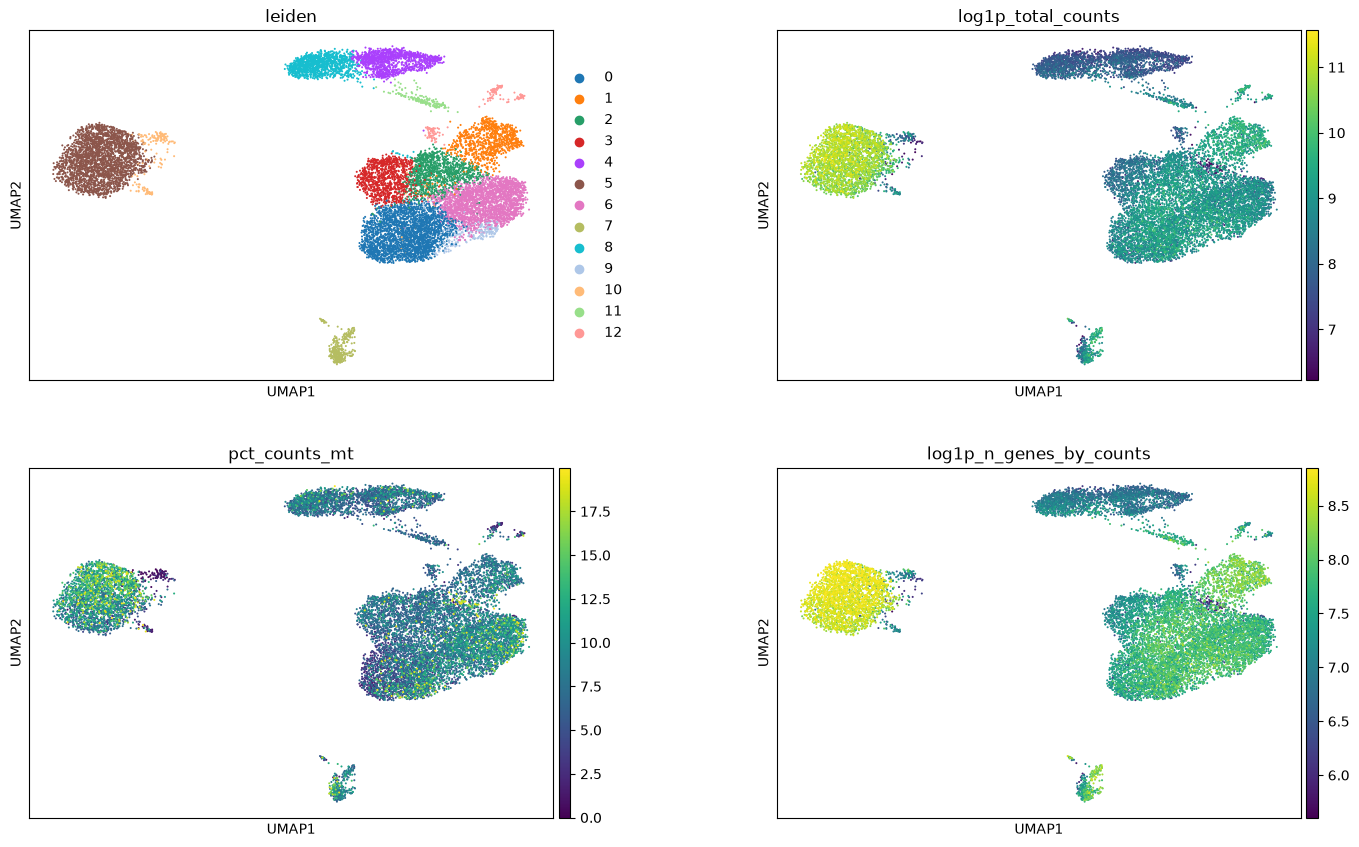

In [18]:
sc.pl.umap(
    hcc1_normalized,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.3,
    ncols=2,
)

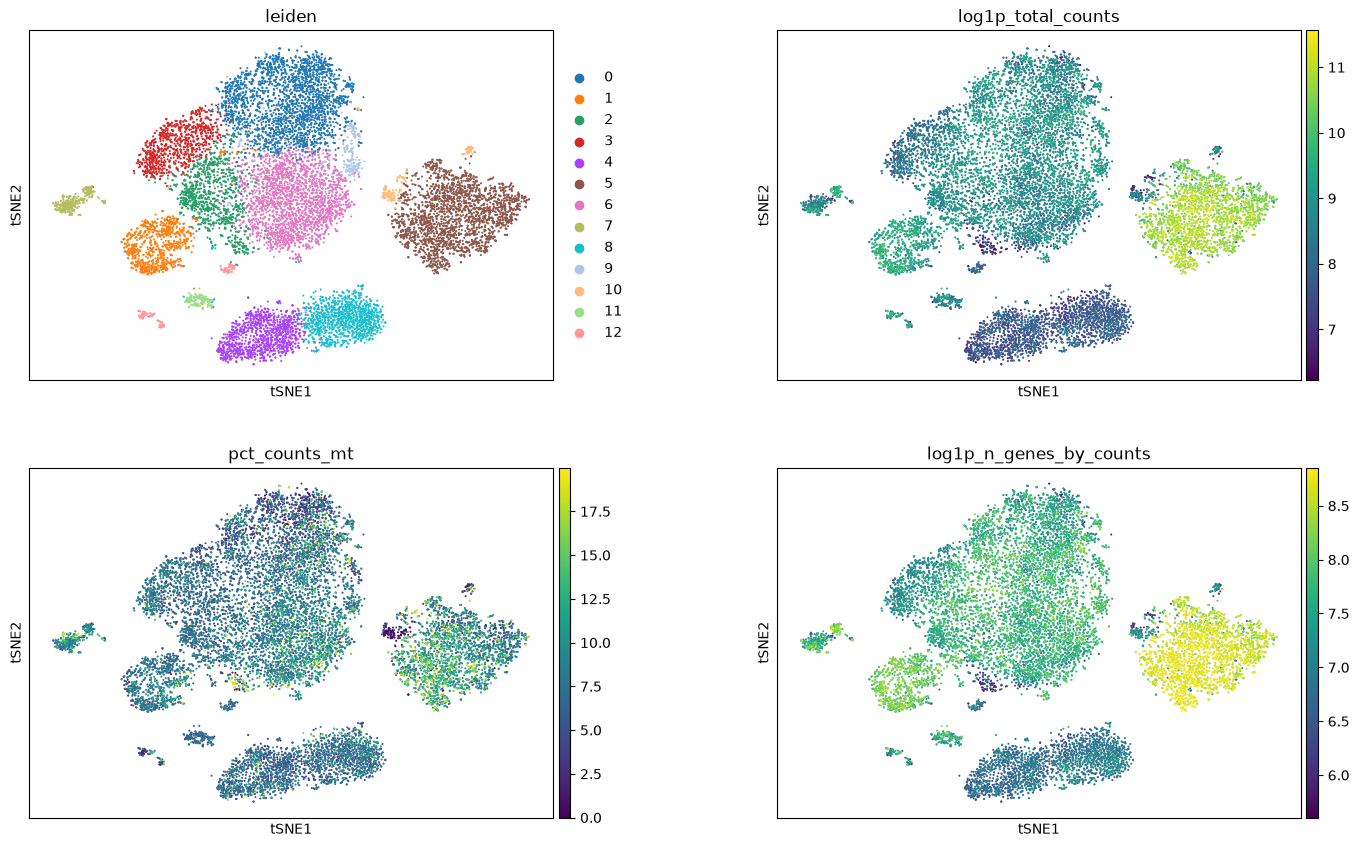

In [19]:
sc.pl.tsne(
    hcc1_normalized,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.3,
    ncols=2,
)

Usamos "**umap**", tarda bastante menos, para probar el número de vecinos y ***resolution*** (número de clústers), intentando determinar los valores que devuelven un resultado razonable.

In [18]:
v = 6 # Índice para indicar qué número de vecinos usar
vecinos = [10, 15, 20, 25, 30, 35, 40, 50]
resoluciones = [0.2, 0.4, 0.5, 0.7, 1.0, 1.2, 1.4, 1.5, 1.7, 2.0]

sc.pp.neighbors(hcc1_normalized, n_neighbors=vecinos[v])
sc.tl.umap(hcc1_normalized, random_state=42)
for r in resoluciones:
    sc.tl.leiden(hcc1_normalized, key_added=f"leiden_n_{vecinos[v]}_res_{r:4.2f}", resolution=r, flavor="igraph")

La semilla ["42"](https://es.wikipedia.org/wiki/El_sentido_de_la_vida,_el_universo_y_todo_lo_dem%C3%A1s) que fijamos al hacer **umap** solo sirve para que los resultados sean reproducibles, pero no es muy necesario. Al final los grafos tienen una estructura parecida, pueden variar en posición u orentación pero al final siguen siendo lo mismo, esto se debe a que se calcula la matriz de vecinos con parámetros distintos.

In [ ]:
grafos = [
    f"leiden_n_{vecinos[v]}_res_{r:4.2f}"
    for r in resoluciones
]

sc.pl.umap(
    hcc1_normalized,
    color=grafos,
    legend_loc="on data",
    show=False, # No mostramos el gráfico
)

# Generamos un fichero que guarda la figura
plt.savefig(
    f"figures/umaps_n_{vecinos[v]}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

Si fijamos la resolución a 1 y miramos el parámetro de número de vecinos:

<div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 6px;">
    <img src="./figures/n10.png" style="width:100%;">
    <img src="./figures/n15.png" style="width:100%;">
    <img src="./figures/n20.png" style="width:100%;">
    <img src="./figures/n25.png" style="width:100%;">
    <img src="./figures/n30.png" style="width:100%;">
    <img src="./figures/n35.png" style="width:100%;">
    <img src="./figures/n40.png" style="width:100%;">
    <img src="./figures/n50.png" style="width:100%;">
</div>


Se puede ver que hay una clara diferenciación de 4 grupos arriba, abajo, izquierda y derecha. Para facilitar referenciar cada uno de las zonas determino un convenio como se muestra en la siguiente imagen:

<img src="./figures/umap_convenio.png" width="50%">

En el caso de 10 vecinos, se interpolan dos clústers en una zona y no hay una clara diferenciación de cuál es cuál, por lo que no parece una opción considerable.

Luego hay casos donde en la **zona 1** se pueden determinar uno o dos clústers, siendo ejemplo "leiden_n_15_res_1.00" y "leiden_n_35_res_1.00", los dos casos pueden ser aceptables. La **zona 4** los clústers están estables, siendo siempre 3 en esa zona, a diferencia de la **zona 3**, donde pueden haber 2 o 3 clústers.

Por último la **zona 2** es donde hay un poco más de variedad, en "leiden_n_50_res_1.00" engloba demasiadas muestras en un mismo clúster, por lo que podría no ser muy apto si queremos datos más locales, a parte de este caso las demás representaciones pueden ser lógicas, aunque tengan clústers en el centro como es el caso de 15 y 25 vecinos o tener un clúster 7 (15 vecinos) o 9 (30, 35, 40 vecinos) adicional, dependiendo del caso.

En posteriores análisis se excluye el uso de **10** y **50 o más** vecinos, también se fomentará el uso de un número **mínimo** de vecinos, facilitando un poco el trabajo de Leiden.

Vamos a fijar a 15 vecinos por se el por defecto de scanpy y modificamos el parámetro *resolution*.

![Imagen con los UMAPS de 15 vecinos probando con distintos valores de resolution](./figures/umaps_n_15.png)

Este parámetro controla de forma más directa el número de clústers, con un valor más grande se generan más clústers. Se puede ver que con una resolución menor de 0.5 hay poco nivel de detalle, en cambio si usamos una resolución mayor de 1.5 hay indicios de que se generan más clústers de la cuenta causando *overfit*. Un valor entre medio puede ser ajustado.

En la celda siguiente podemos calcular el **Silhouette score**, valores comprendidos entre 1 y -1, valores cercanos a 0 indica que que hay clústers solapados y un valor negativo significa que hay varias muestras asignadas a un clúster incorrecto. **Calinski-Harabasz Index** es una métrica parecida a la anterior, un valor alto significa que los clústers están bien formados. Por otra parte, **Davies-Bouldin Index** devuelve valores altos si los clústers están **mal** formados.

In [21]:
vecinos = [15, 20, 25, 30, 35, 40]
resoluciones = [0.2, 0.4, 0.5, 0.7, 1.0, 1.2, 1.4, 1.5, 1.7, 2.0]

resultados = []

for n in vecinos:
    for r in resoluciones:

        key = f"leiden_n_{n}_res_{r:4.2f}"

        labels = hcc1_normalized.obs[key]

        s_score = silhouette_score(hcc1_normalized.obsm["X_pca"], labels)
        c_score = calinski_harabasz_score(hcc1_normalized.obsm["X_pca"], labels)
        d_score = davies_bouldin_score(hcc1_normalized.obsm["X_pca"], labels)

        n_clusters = labels.nunique()

        resultados.append({
            "n_neighbors": n,
            "resolution": r,
            "silhouette": s_score,
            "calinski": c_score,
            "davies": d_score,
            "n_clusters": n_clusters
        })

df_resultados = pd.DataFrame(resultados)

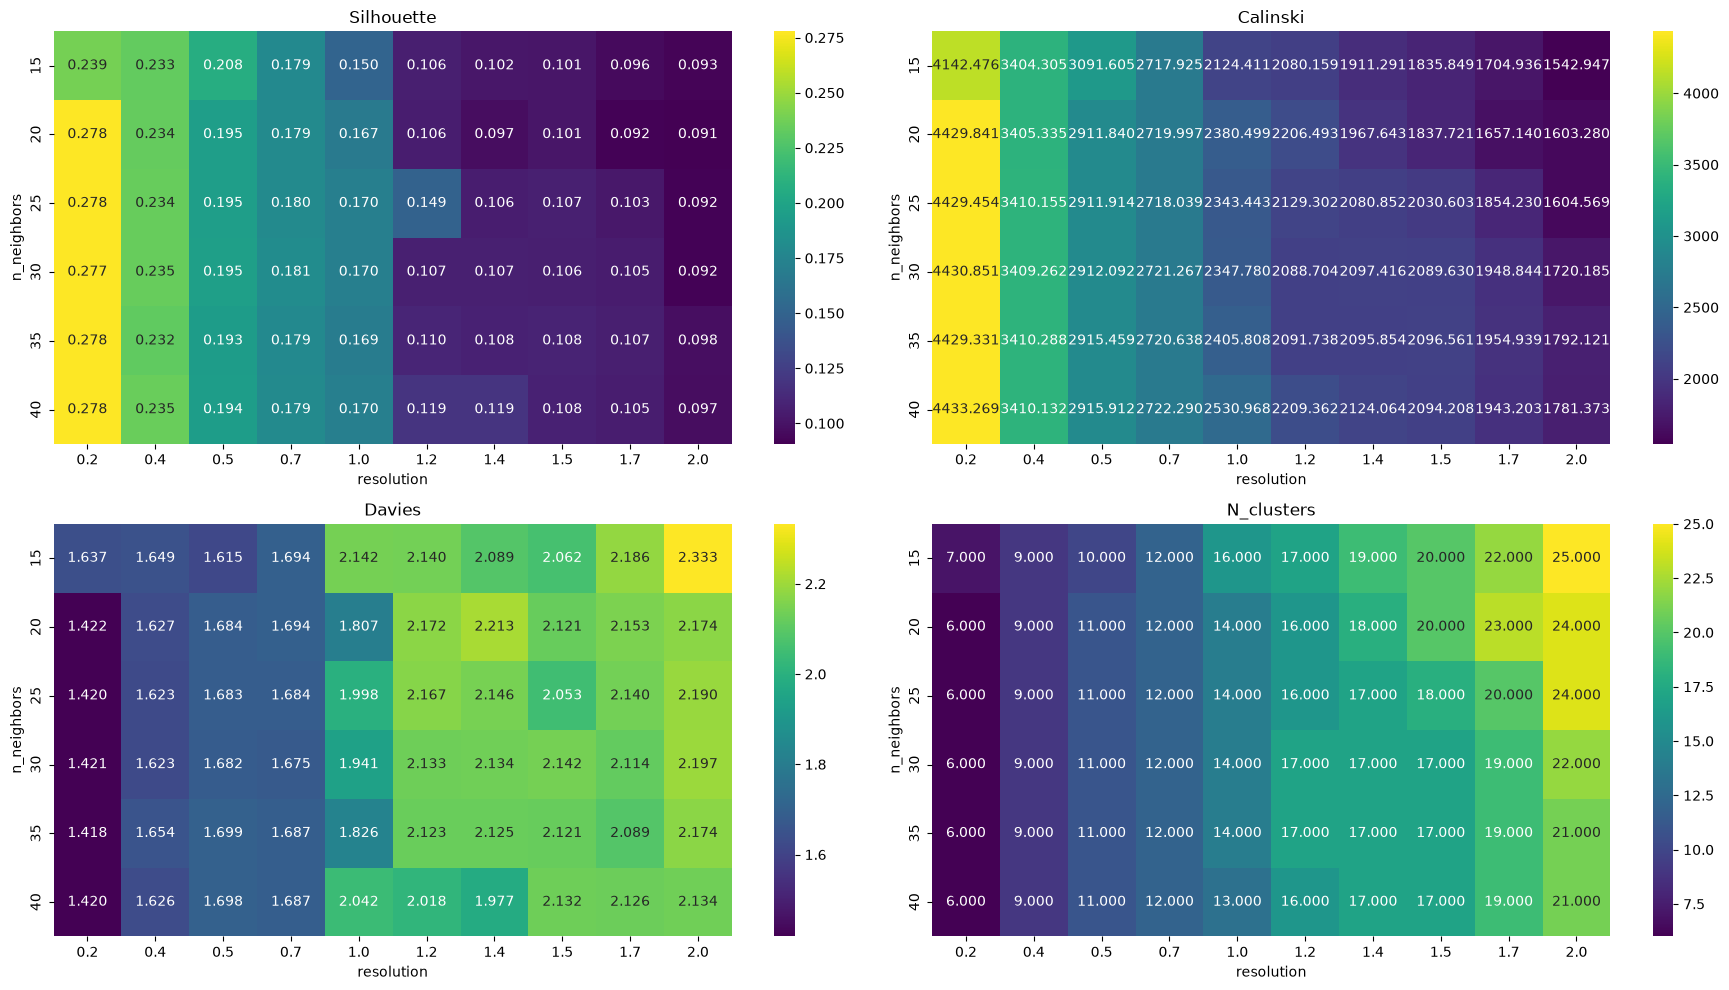

In [35]:
metricas = ["silhouette", "calinski", "davies", "n_clusters"]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for ax, metrica in zip(axes.flat, metricas):
    pivot = df_resultados.pivot(
        index="n_neighbors",
        columns="resolution",
        values=metrica
    )

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        ax=ax
    )

    ax.set_title(metrica.capitalize())
    ax.set_xlabel("resolution")
    ax.set_ylabel("n_neighbors")

plt.tight_layout()
plt.show()

Estos scores calculan qué tan bien separados están las muestras de otros clústers.

Si calculamos el score en el caso que estamos trabajando, vemos que conforme se aumenta el valor de ***resolution*** se obtiene un valor peor del score, consecuencia del ***overfitting***. Un mejor valor del score no significa que el clustering sea bueno, con un valor menor de ***resolution*** se consigue mejor score pero en realidad se está perdiendo información detallada, por lo que siempre hay que tener en cuenta la **realidad** biológica, la cual se tratará en apartados posteriores.

De momento, al igual que se deducía previamente, valores de ***resolution*** mayor que 1.5 no generalizan muy bien, por lo que se podría descartar.

#### 3.4. Identificación de células

Vamos a intentar identificar las células que representan las muestras que hemos clasificado, se va a realizar de forma manual la anotación del tipo de células de cada clúster. Después también se utilizarán [métodos automáticos](https://www.sc-best-practices.org/cellular-structure/annotation/#cellular-structure-annotation-key-takeaway-3) de clasificación y se hará una comparación.

In [19]:
# Ordenar genes de los clusters, en este caso se usan el clustering de 15 vecinos y resolución 1.
sc.tl.rank_genes_groups(hcc1_normalized, groupby="leiden_n_15_res_1.00", method="wilcoxon")

In [ ]:
# Obtenemos una gráfica con los 5 genes más expresados de los clusters
sc.pl.rank_genes_groups_dotplot(hcc1_normalized, groupby="leiden_n_15_res_1.00", standard_scale="var", n_genes=5, show=False)

plt.savefig("figures/dotplot_leiden_n_15_res_1.00.png", dpi=300, bbox_inches="tight")

plt.close()

Después de obtener los genes más expresados de cada clúster, se pueden usar herramientas como [**CellMaker**](https://bio-bigdata.hrbmu.edu.cn/CellMarker/#/home) para obtener células a partir de genes que los caracterizan.

Es un proceso tedioso y con cierta incertidumbre, porque la herramienta devuelve varios resultados ordenados por score (confidence), por lo que hay que decidir de forma humana cada célula, pudiendo generar errores.

De forma resumida:

- Cluster 6 (ALB, SERPINA1, VTN, AMBP, APOA2): Endothelial cell of sinusoid, Neutrophil progenitor cell, Hepatocyte
- Cluster 11 (APOA2, RPL8, SERPINA1, SPINK1, RPL7): Neutrophil progenitor cell, Hepatocyte, CD8+ T cell
- Cluster 2 (HLA-DRB1, CST3, HLA-DPB1, HLA-DRA, HLA-DPA1): Conventional dendritic cell 2, Myeloid cell, Classical dendritic cell
- Cluster 4 (FCN1, LYZ, S100A9, LST1, S100A8): Inflammatory macrophage, CD14+ monocyte, Myeloid cell
- Cluster 0 (SPP1, VIM, CSTB, IL1B, CTSB): Macrophage, Monocyte, Tumor-associated macrophage
- Cluster 3 (CSTB, VIM, FTL, S100A10, LGALS1): Monocyte, Macrophage, Professional antigen presenting cell
- Cluster 10 (MT1G, MT2A, MT1X, CTSB, LGMN): Metallothionein-associated macrophage, Tumor-associated macrophage, Liver bud hepatic cell
- Cluster 7 (CCL4, C1QB, C1QA, SLC40A1, SEPP1): Macrophage, C1Q+ macrophage, Myeloid cell
- Cluster 12 (SLC40A1, SEPP1, C1QA, C1QB, LGMN): C1Q+ macrophage, Macrophage, Tumor-associated macrophage
- Cluster 13 (CD79A, MZB1, IGKC, JCHAIN, IGHG1): Plasma cell, Immnune cell, Erythrocyte
- Cluster 5 (RPS27, RPS15A, RPS29, RPS12, IL32): Double-negative T cell, Lymphocyte, T cell
- Cluster 9 (IL32, HLA-A, TRAC, CD3D, B2M): T cell, Lymphocyte, CD8+ T cell
- Cluster 1 (STMN1, TUBA1B, H2AFZ, TUBB, HMGN2): Pre-B cell, Mid erythroid cell, T cell
- Cluster 14 (HMGB2, HMGB1, STMN1, PTMA, TUBA1B): T cell, Cycling T cell, Pre-B cell
- Cluster 8 (SPARC, IGFBP7, COL1A2, COL3A1, CALD1): Stellate cell, Cancer associated fibroblast, Fibroblast
- Cluster 15 (STC1, MCAM, IGFBP7, ADGRL4, GNG11): Endothelial cell, Portal endothelial cell, Myofibroblast

Puede que sea necesario poner más genes porque no soy biólogo

# TODO:
- Clasificar exhausted y non_exhausted
- FBA